# Проверка генератора синтетики (`src/synth`)

Визуальный sanity-check: свип curriculum, натуральные строки, скорость.

Перед запуском положите шрифты в `assets/fonts/` (`python scripts/fetch_fonts.py`).

In [1]:
import sys, time
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import matplotlib.pyplot as plt
from src.synth import HandwrittenLineGenerator, SynthConfig, make_generator
from src.synth.config import FontConfig

cfg = SynthConfig(font=FontConfig(font_dirs=(str(ROOT / 'assets' / 'fonts'),)))
gen = HandwrittenLineGenerator(cfg)
print(f'fonts: {len(gen.fonts)} | effects backend: {gen.effects.backend}')

fonts: 72 | effects backend: fallback


## Свип curriculum (строки = сложность t, столбцы = сэмплы)

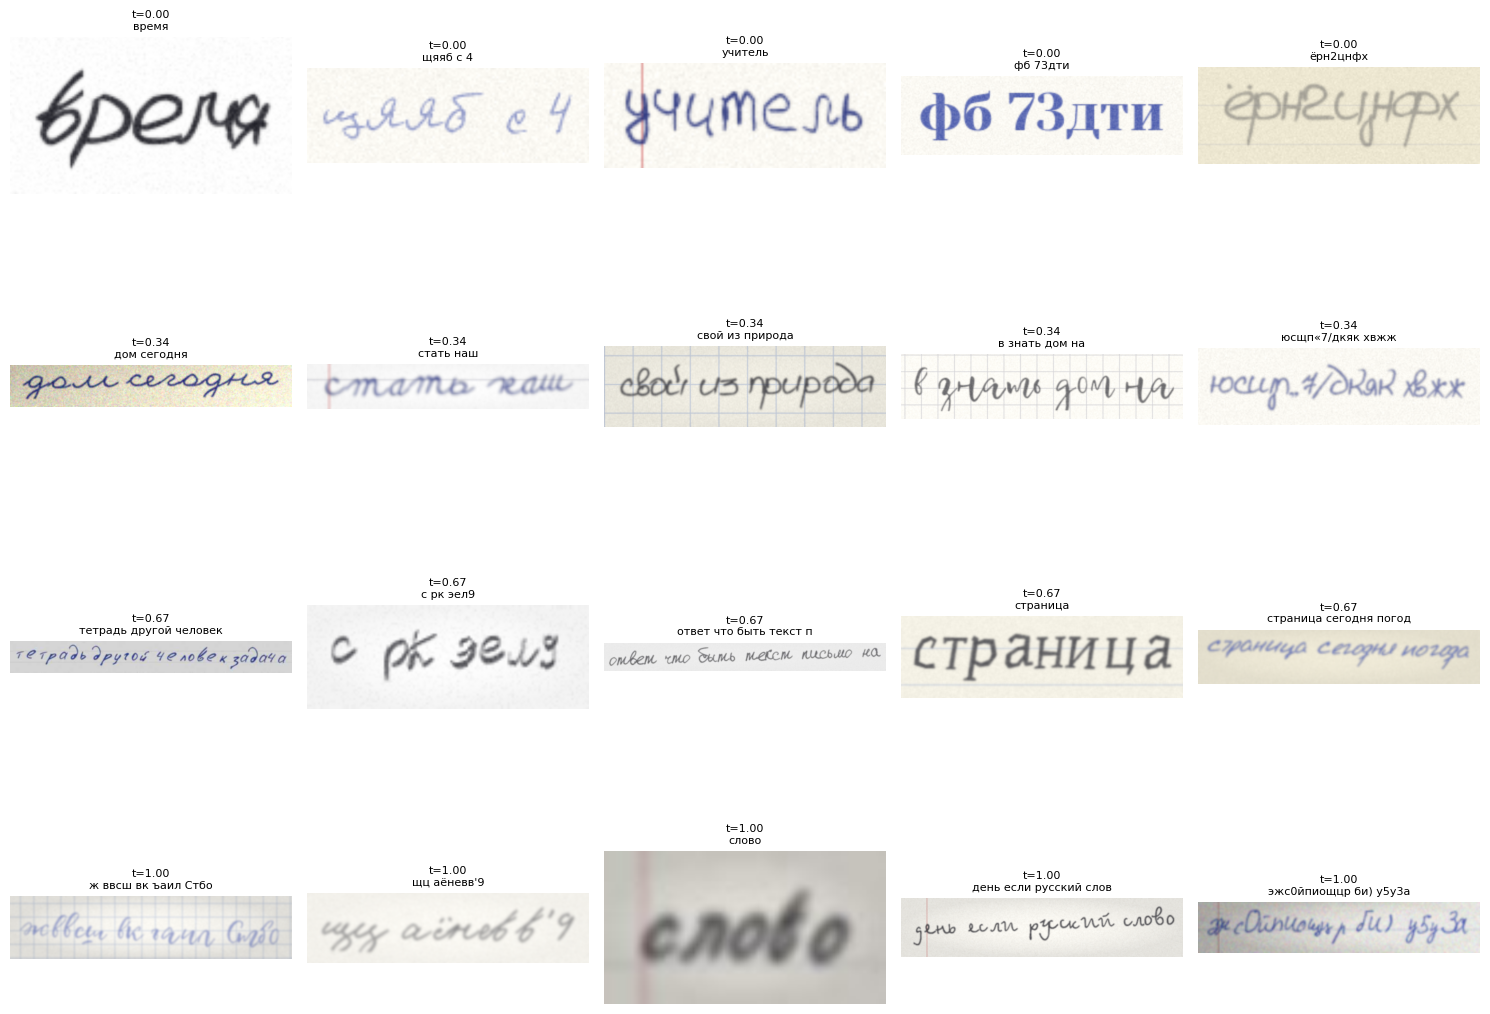

In [2]:
rows, ncol = [0.0, 0.34, 0.67, 1.0], 5
fig, axes = plt.subplots(len(rows), ncol, figsize=(ncol * 3, len(rows) * 3))
draw = 0
for r, t in enumerate(rows):
    step = int(t * gen.cfg.warmup_steps)
    for c in range(ncol):
        rng = make_generator(7, 0, draw); draw += 1
        img, text = gen.sample(rng, step)
        axes[r][c].imshow(img); axes[r][c].axis('off')
        axes[r][c].set_title(f't={t:.2f}\n{text[:22]}', fontsize=8)
plt.tight_layout(); plt.show()

## Натуральные строки (как выглядит до letterbox)

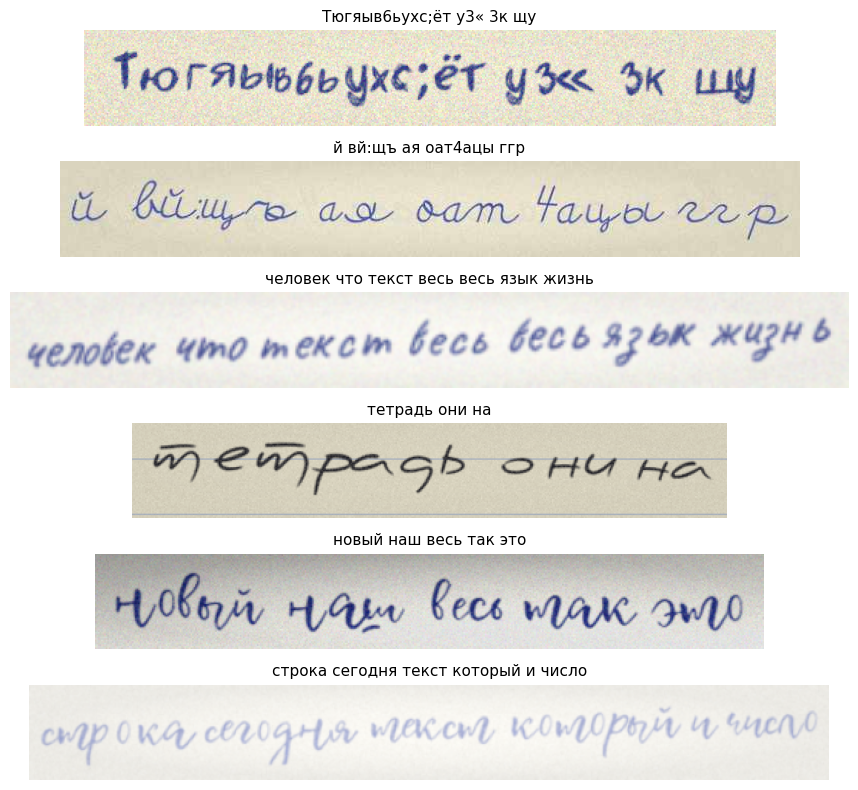

In [4]:
fig, axes = plt.subplots(6, 1, figsize=(11, 8))
for i, ax in enumerate(axes):
    img, text = gen.render_line(make_generator(21, 0, i), gen.cfg.warmup_steps)
    ax.imshow(img); ax.axis('off'); ax.set_title(text, fontsize=11)
plt.tight_layout(); plt.show()

## Пропускная способность (1 воркер)

In [5]:
n = 100; t0 = time.perf_counter()
for i in range(n):
    gen.sample(make_generator(3, 0, i), gen.cfg.warmup_steps)
dt = time.perf_counter() - t0
print(f'{n / dt:.0f} lines/s  ({1000 * dt / n:.2f} ms/line)')

45 lines/s  (22.06 ms/line)
